# Software Development Lifecycle using Lang-Graph

In [46]:
import sys
print(sys.executable)

c:\Github\SDLC-using-Lang-Graph\env\Scripts\python.exe


In [47]:
from typing import Annotated, TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

In [48]:
class State(TypedDict):
    messages : Annotated[list, add_messages]

In [49]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [50]:
from langchain_openai import ChatOpenAI

In [ ]:
llm = ChatOpenAI(
    model = "gpt-4.1-mini",
    temperature = 0.5
)

In [52]:
from langchain_core.tools import tool
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langgraph.types import Command, interrupt
import datetime

In [53]:
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()
config = {"configurable": {"thread_id" : "1"}}

In [54]:
import sys
from pathlib import Path

# Go up one directory from "testing grounds" to the project root
project_root = Path.cwd().parent

sys.path.append(str(project_root))

In [55]:
from tools.planner import create, append, rewrite, read_plan, summarize_plan, update_plan

In [56]:
tools = [create, append, rewrite, read_plan, summarize_plan, update_plan]

In [57]:
planner = llm.bind_tools(tools = tools)

def planning_agent(state:State):
    response = planner.invoke(state["messages"])
    return {"messages": [response]}

In [58]:
planner.invoke("hello")

AIMessage(content='Hello! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 10, 'prompt_tokens': 504, 'total_tokens': 514, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4.1-mini-2025-04-14', 'system_fingerprint': 'fp_021b121185', 'id': 'chatcmpl-E4kbwCuShuRDQjmJOXx3iAVq0aF07', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019f8e70-b855-7b32-afd4-d3549f0055f7-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 504, 'output_tokens': 10, 'total_tokens': 514, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [65]:
graph_builder = StateGraph(State)

graph_builder.add_node("Planner", planning_agent)
graph_builder.add_node("tools", ToolNode(tools=tools))

graph_builder.add_edge(START, "Planner")
graph_builder.add_conditional_edges(
    "Planner",
    tools_condition
)
graph_builder.add_edge("tools", "Planner")

graph = graph_builder.compile(checkpointer=memory)

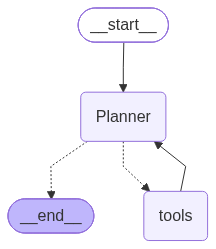

In [66]:
graph

In [73]:
from langchain_core.messages import HumanMessage

response = graph.invoke({"messages" : [
    HumanMessage(content="I want to create a tic tac toe game which can be played between 2 peoples, the score of previous matches is displayed on  the screen until the session is terminated and it should follow general tic tac toe rules"),
    
]},config=config
)

In [75]:
for m  in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

I  want to create a tic tac toe  game which can  handle 2 players and the score  is displayed on the screen whenever a session is ongoing and  the players should have alternate turns  just like the real game.
================================ Human Message =================================

I want to create a tic tac toe game which can be played between 2 peoples, the score of previous matches is displayed on  the screen until the session is terminated and it should follow general tic tac toe rules
================================== Ai Message ==================================
Tool Calls:
  read_plan (call_mgAHLUOWAPlxDr4oK7VAo962)
 Call ID: call_mgAHLUOWAPlxDr4oK7VAo962
  Args:
================================= Tool Message =================================
Name: read_plan

plan.md does not exist, use create to initialize plan.md
================================== Ai Message =============================